# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [1]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import string

# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

### Read Files

In [2]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)
summaries

[   scenario  early_yr  late_yr  mean_pred  accuracy
 0    ssp119      2015     2025   0.470245      0.82
 1    ssp119      2015     2035   0.410600      0.84
 2    ssp119      2015     2045   0.466150      0.98
 3    ssp119      2015     2055   0.430172      0.90
 4    ssp119      2015     2065   0.532195      0.92
 5    ssp119      2015     2075   0.595301      0.90
 6    ssp119      2015     2085   0.489195      0.68
 7    ssp119      2025     2035   0.541241      0.66
 8    ssp119      2025     2045   0.540277      0.74
 9    ssp119      2025     2055   0.572211      0.70
 10   ssp119      2025     2065   0.642615      0.50
 11   ssp119      2025     2075   0.616965      0.50
 12   ssp119      2025     2085   0.587658      0.48
 13   ssp119      2035     2045   0.531505      0.56
 14   ssp119      2035     2055   0.485640      0.50
 15   ssp119      2035     2065   0.473414      0.72
 16   ssp119      2035     2075   0.578257      0.62
 17   ssp119      2035     2085   0.512858    

### Calculations

In [5]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries):
    # Make a df to hold: 
    # a) metadata
    acc_df = pd.DataFrame(columns=['scenario','early_yr', 'late_yr'])
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early_yr']
    acc_df['late'] = summaries[0]['late_yr']
    
    # b) accuracies
    for i in range(len(csvs)):
        acc_df[f"acc_{i}"] = summaries[i]['accuracy']
    
    # c) mean and std
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    acc_df['std'] = acc_df[acc_cols].std(axis=1)
    
    return acc_df

In [6]:
mean_std = get_mean_std(summaries)
mean_std.head()

,scenario,early_yr,late_yr,early,late,acc_0,acc_1,mean,std
0,ssp119,NaN,NaN,2015,2025,0.82,0.76,0.79,0.042426
1,ssp119,NaN,NaN,2015,2035,0.84,0.82,0.83,0.014142
2,ssp119,NaN,NaN,2015,2045,0.98,0.88,0.93,0.070711
3,ssp119,NaN,NaN,2015,2055,0.90,0.50,0.70,0.282843
4,ssp119,NaN,NaN,2015,2065,0.92,0.62,0.77,0.212132


### Making a Matrix

In [7]:
# Make a copy
mean_std = mean_std.copy()
# Create the label pairings by changing scenario-early-late to a single, concatenated index
mean_std['label'] = mean_std['scenario'] + '_' + mean_std['early'].astype(str) + '_' + mean_std['late'].astype(str)
mean_std = mean_std.drop(columns=['scenario', 'early', 'late'])
# Drop the acc columns
mean_std = mean_std.drop(columns=[col for col in mean_std.columns if col.startswith('acc_')])
mean_std.set_index('label', inplace=True)
mean_std_119 = mean_std.filter(like='119', axis=0)
mean_std_126 = mean_std.filter(like='126', axis=0)
mean_std_119.head()

,early_yr,late_yr,mean,std
label,,,,
ssp119_2015_2025,NaN,NaN,0.79,0.042426
ssp119_2015_2035,NaN,NaN,0.83,0.014142
ssp119_2015_2045,NaN,NaN,0.93,0.070711
ssp119_2015_2055,NaN,NaN,0.70,0.282843
ssp119_2015_2065,NaN,NaN,0.77,0.212132


Adapted from Max Pierini on Stack Overflow

Source - https://stackoverflow.com/a/66823998

Posted by Max Pierini, modified by community. See post 'Timeline' for change history

Retrieved 2026-04-13, License - CC BY-SA 4.0

In [8]:
def turn_into_matrix_df(mean_std_scenario):
    values = [a - b for a, b in combinations(mean_std_scenario['mean'], 2)]
    index = [f"{a} vs {b}" for a, b in combinations(mean_std_scenario.index, 2)]
    sr = pd.Series(values, index = index)
    
    df = sr.reset_index()
    df.columns = ['row_col', 'data']

    # Add missing values, will leave blank when actually plotting
    df_inv = pd.DataFrame({
        'row_col': [f"{b} vs {a}" for a, b in combinations(mean_std_scenario.index, 2)],
        'data': df.data * -1
        })
    
    df_values = pd.concat([df,df_inv])
    df_values[['row', 'col']] = df_values.row_col.str.split(' vs ', expand=True)

    df_piv = df_values[['row', 'col', 'data']].pivot(index='row', columns='col').fillna(0).astype(float)


    return df_piv

df_119 = turn_into_matrix_df(mean_std_119)
df_126 = turn_into_matrix_df(mean_std_126)
df_119

data                                    \
col              ssp119_2015_2025 ssp119_2015_2035 ssp119_2015_2045   
row                                                                   
ssp119_2015_2025             0.00            -0.04            -0.14   
ssp119_2015_2035             0.04             0.00            -0.10   
ssp119_2015_2045             0.14             0.10             0.00   
ssp119_2015_2055            -0.09            -0.13            -0.23   
ssp119_2015_2065            -0.02            -0.06            -0.16   
ssp119_2015_2075             0.15             0.11             0.01   
ssp119_2015_2085             0.03            -0.01            -0.11   
ssp119_2025_2035            -0.21            -0.25            -0.35   
ssp119_2025_2045            -0.04            -0.08            -0.18   
ssp119_2025_2055             0.01            -0.03            -0.13   
ssp119_2025_2065            -0.06            -0.10            -0.20   
ssp119_2025_2075            -0.16            -0.20            -0.30   
ssp119_2025_2085            -0.10            -0.14            -0.24   
ssp119_2035_2045            -0.29            -0.33            -0.43   
ssp119_2035_2055            -0.23            -0.27            -0.37   
ssp119_2035_2065            -0.05            -0.09            -0.19   
ssp119_2035_2075            -0.15            -0.19            -0.29   
ssp119_2035_2085             0.11             0.07            -0.03   
ssp119_2045_2055            -0.13            -0.17            -0.27   
ssp119_2045_2065            -0.13            -0.17            -0.27   
ssp119_2045_2075            -0.24            -0.28            -0.38   
ssp119_2045_2085             0.06             0.02            -0.08   
ssp119_2055_2065            -0.34            -0.38            -0.48   
ssp119_2055_2075            -0.12            -0.16            -0.26   
ssp119_2055_2085            -0.07            -0.11            -0.21   
ssp119_2065_2075            -0.12            -0.16            -0.26   
ssp119_2065_2085            -0.18            -0.22            -0.32   
ssp119_2075_2085            -0.21            -0.25            -0.35   

                                                                     \
col              ssp119_2015_2055 ssp119_2015_2065 ssp119_2015_2075   
row                                                                   
ssp119_2015_2025             0.09             0.02            -0.15   
ssp119_2015_2035             0.13             0.06            -0.11   
ssp119_2015_2045             0.23             0.16            -0.01   
ssp119_2015_2055             0.00            -0.07            -0.24   
ssp119_2015_2065             0.07             0.00            -0.17   
ssp119_2015_2075             0.24             0.17             0.00   
ssp119_2015_2085             0.12             0.05            -0.12   
ssp119_2025_2035            -0.12            -0.19            -0.36   
ssp119_2025_2045             0.05            -0.02            -0.19   
ssp119_2025_2055             0.10             0.03            -0.14   
ssp119_2025_2065             0.03            -0.04            -0.21   
ssp119_2025_2075            -0.07            -0.14            -0.31   
ssp119_2025_2085            -0.01            -0.08            -0.25   
ssp119_2035_2045            -0.20            -0.27            -0.44   
ssp119_2035_2055            -0.14            -0.21            -0.38   
ssp119_2035_2065             0.04            -0.03            -0.20   
ssp119_2035_2075            -0.06            -0.13            -0.30   
ssp119_2035_2085             0.20             0.13            -0.04   
ssp119_2045_2055            -0.04            -0.11            -0.28   
ssp119_2045_2065            -0.04            -0.11            -0.28   
ssp119_2045_2075            -0.15            -0.22            -0.39   
ssp119_2045_2085             0.15             0.08            -0.09   
ssp119_2055_2065            -0.25            -0.32  

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_24378/608294025.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['']+labels)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_24378/608294025.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['']+labels)


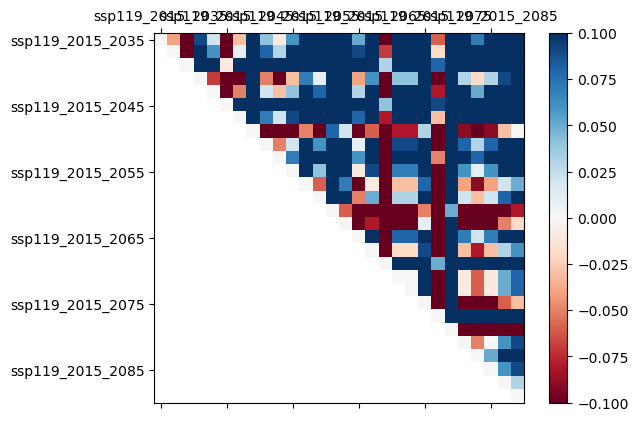

In [9]:
# Function to plot with colors and labels
def matshow_plot(df):
    labels = df.index
    data = df

    # Mask lower triangle
    mask = np.tril(np.ones_like(data), k=-1)
    data[mask == 1] = np.nan

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(data, interpolation='nearest', cmap='RdBu', vmin=-np.max(np.abs(data.values)), vmax=np.max(np.abs(data.values)))    
    fig.colorbar(cax)
    ax.set_xticklabels(['']+labels)
    ax.set_yticklabels(['']+labels)

    plt.show()

matshow_plot(df_119)

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_24378/608294025.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['']+labels)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_24378/608294025.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['']+labels)


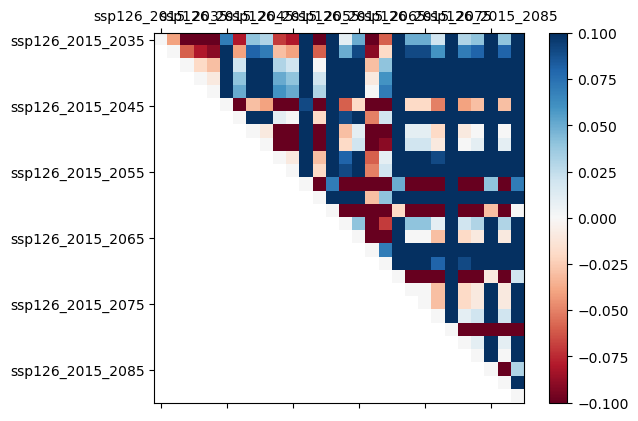

In [10]:
matshow_plot(df_126)

In [ ]:
import seaborn as sns

def improved_heatmap_plot(df, title="Accuracy Difference Matrix"):
    # remove scenario prefix and replace underscore with dash
    df.index = [i.replace('ssp119_', '').replace('_', '-') for i in df.index]
    # replace for column headers too 
        # usse c[1] bc pivot from earilier creted multiindex where actual experiment name is stored in second lvl of col header
    df.columns = [c[1].replace('ssp119_', '').replace('_', '-') for c in df.columns]

    plt.figure(figsize=(14, 10))
    
    # mask for lower part of matrix since irrelelvant bc it just repeats upper part
    mask = np.tril(np.ones_like(df, dtype=bool), k=0)

    ax = sns.heatmap(df, 
                     mask=mask, 
                     cmap='RdBu', 
                     center=0, # ensure that 0 diff is white
                     annot=True,  # add accuracy lables 
                     fmt=".2f",
                     linewidths=.5, 
                     cbar_kws={"shrink": .8, "label": "Accuracy Difference"}) # make cbar smallr and add label

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()

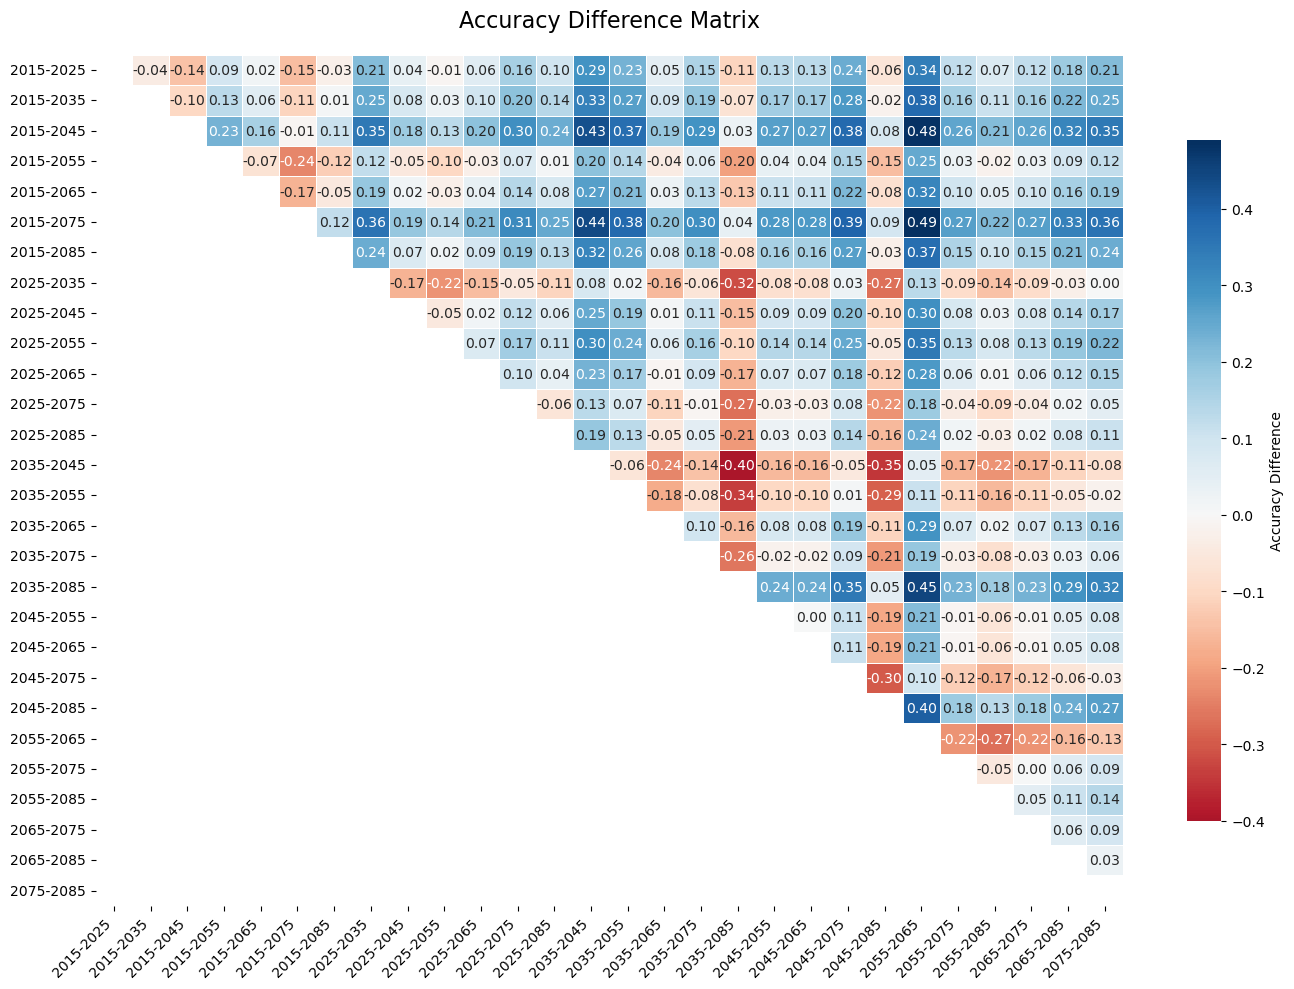

In [12]:
improved_heatmap_plot(df_119)

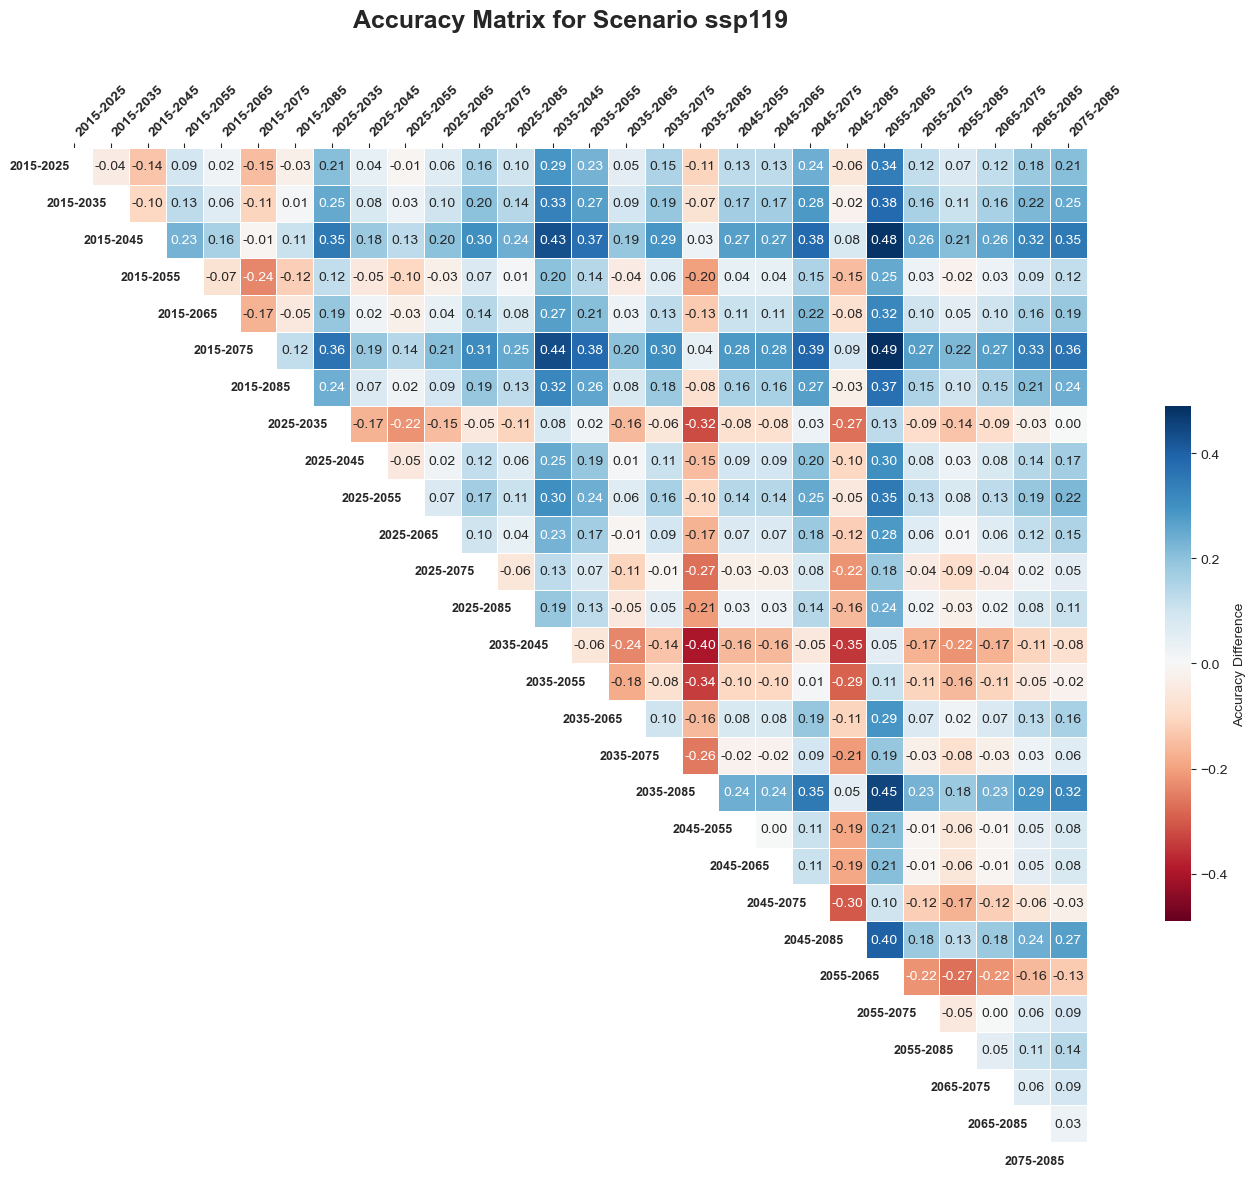

In [ ]:

def final_formatted_heatmap(df, scenario_id="ssp119", prefix="ssp119_"):
    # cleen up labels 
    df.index = [str(i).replace(prefix, '').replace('_', '-') for i in df.index]
    # if col headers are multi-levels
    if hasattr(df.columns, 'levels'):
        df.columns = [str(c[1]).replace(prefix, '').replace('_', '-') for c in df.columns]
    else:
        df.columns = [str(c).replace(prefix, '').replace('_', '-') for c in df.columns]
    # save clean labels to list for manual y axis placement
    labels = df.index.tolist()
    
    plt.figure(figsize=(16, 12))
    
   # create boolean lower triangle filter 
    # k=0 hides the diagonal cells 
    mask = np.tril(np.ones_like(df, dtype=bool), k=0)

    # for symmetrical colorbar
    vmax = np.nanmax(np.abs(df.values))

    # 5. Plot the Heatmap
    # center=0 ensures white represents no difference in accuracy
    ax = sns.heatmap(df, 
                     mask=mask, 
                     cmap='RdBu', 
                     center=0, # ensure that 0 diff is white
                     vmin=-vmax, 
                     vmax=vmax,
                     annot=True, # add accuracy lables 
                     fmt=".2f",
                     square=True,
                     linewidths=.5, 
                     cbar_kws={"shrink": .5, "label": "Accuracy Difference"}) # make cbar smallr and add label

    # moving x axis tick marks and labels to top 
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # styling x axis labels 
    plt.xticks(rotation=45, ha='left', fontweight='bold', fontsize=10)
 



    for i in range(len(labels)):
        # put text in empty space in the lower triangle mask 
        ax.text(i + 0.4, i + 0.5, labels[i], 
                ha='right', va='center', rotation=0, 
                fontsize=9, fontweight='bold')

    # add title 
    plt.title(f"Accuracy Matrix for Scenario {scenario_id}", fontsize=18, fontweight='bold', pad=40)
    # remove set x and y axis labels 
    plt.xlabel("")
    ax.set_yticks([])
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

# Execution example:
final_formatted_heatmap(df_119, scenario_id="ssp119")

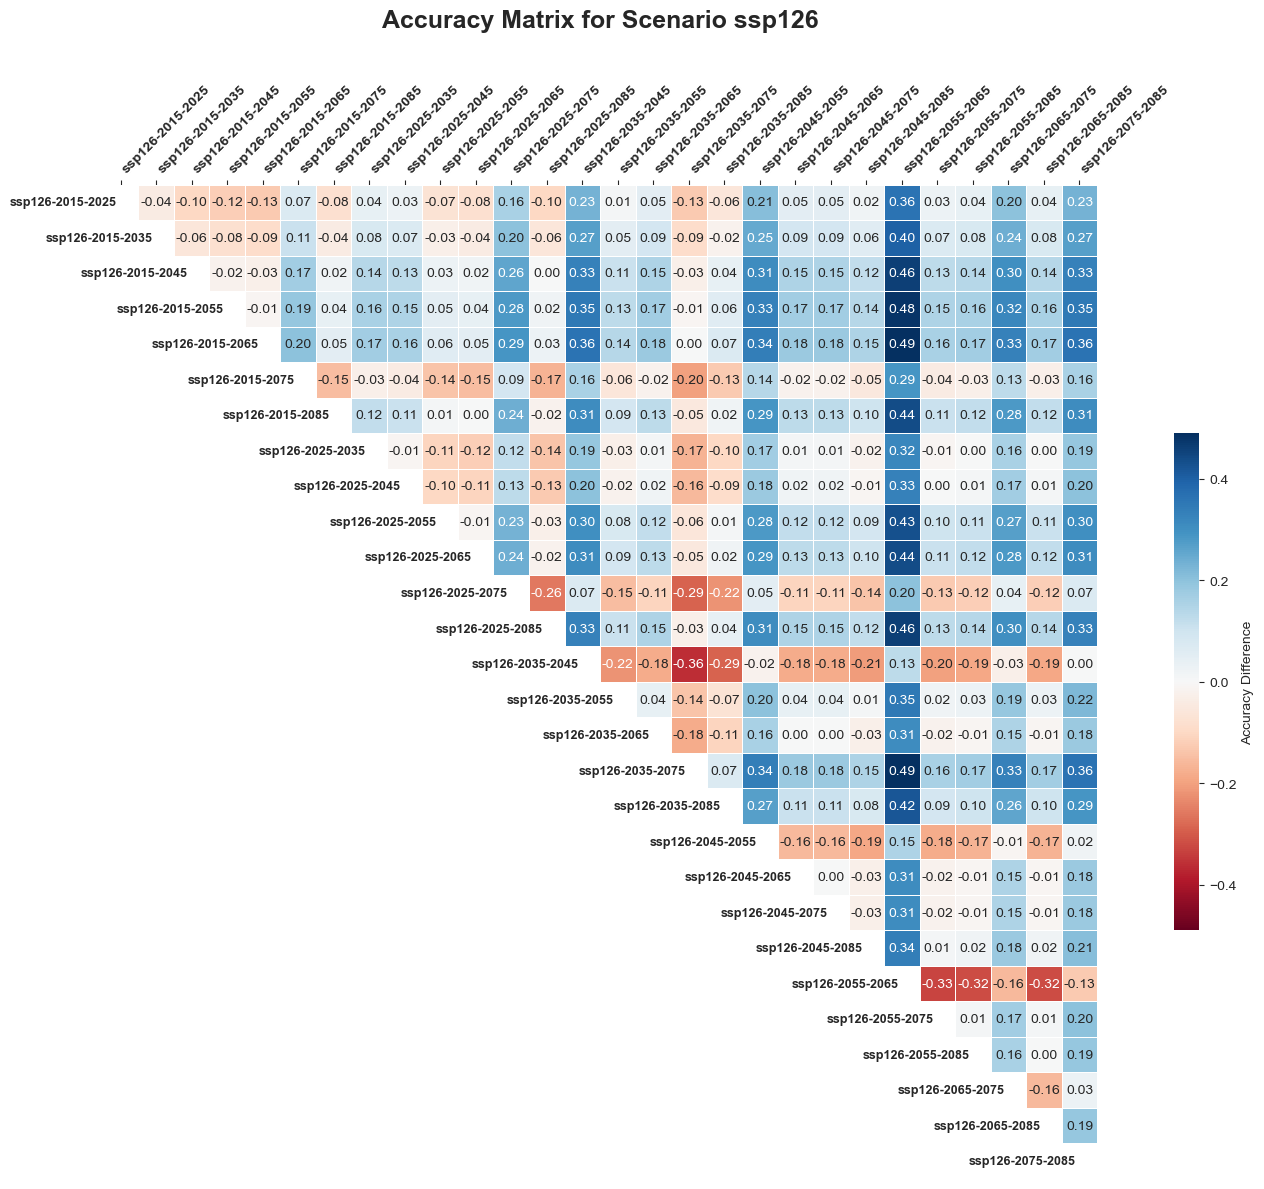

In [32]:
final_formatted_heatmap(df_126, scenario_id="ssp126")